# Подготовка основных типов исходных данных

Для большинства задач расчета параметров прибытия подразделений пожарной охраны и определения оптимальной дислокации в большинстве случаев достаточно следующих данных:

* Границы населенных пунктов и территорий
* Граф улично-дорожной сети
* Сведения о зданиях и сооружениях
* Сведения о подразделениях пожарной охраны

Подготовка исходных данных осуществляется в два этапа:

1. Получение и предварительная обработка
2. Подготовка рабочих наборов данных

Получение и предварительная обработка данных выполняются за счет получения пространственных данных из открытых источников. Основным источником пространственных данных о населенных пунктах рекомендуется рассматривать сервис [OpenStreetMap](https://www.openstreetmap.org/).

Некоторые данные, такие как, места размещения ПСЧ в открытом доступе либо отсутствуют, либо являются неполными или ошибочными. Такие данные лучше заполнять на основе имеющихся в расположении пользователей данных.

Окончательная подготовка рабочих наборов данных выполняется как правило в приложении QGIS и заключается в сверке полученных данных с реальностью - добавление отсутствующих данных, исправление ошибочных и обогащение дополнительными данными.

Ниже описан процесс получения данных с использованием средств языка программирования `Python`.

## Требуемые библиотеки

In [80]:
import osmnx as ox
import pandas as pd
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt

# Печатаем версии библиотек
print('OSMnx:', ox.__version__,
      '\nGeoPandas:', gpd.__version__,
      '\nPandas:', pd.__version__,
      '\nContextily', ctx.__version__,
      )

OSMnx: 2.0.1 
GeoPandas: 1.0.1 
Pandas: 2.2.2 
Contextily 1.6.2


## Данные о границе населенного пункта

Название городов рекомендуется указывать в формате

`город`, `субъект`, `страна`

In [14]:
# Получение данных по названию населенного пункта
city_name = 'Кемерово, Кемеровская область, Россия'
borders = ox.geocode_to_gdf(city_name)

# Сохранение в файл `GeoPackage` 
borders.to_file('data/kemerovo/borders.gpkg', driver = 'GPKG')

# Просмотр карты
borders.explore()

## Граф улично-дорожной сети

### Загрузка ГДС (в пределах полигона границ с буферной зоной)

Название городов рекомендуется указывать в формате

`город`, `субъект`, `страна`

Количество вершин: 18440
Количество ребер: 44634


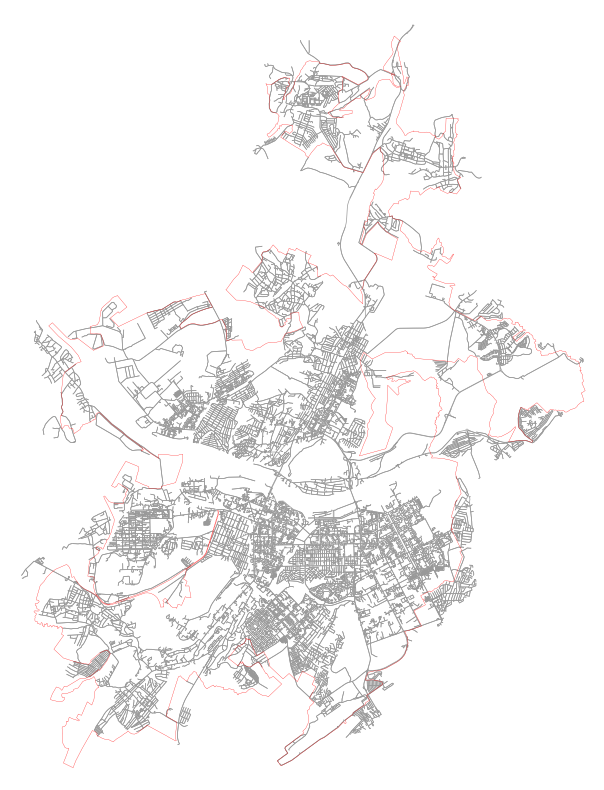

In [90]:
# Разрешаем выгружать данные частных дорог
ox.settings.default_access = ''

# Размер буферной зоны в метрах
buffer_size = 1000

# Получение полигона с буферной зоной
borders_buffer = ox.projection.project_gdf(borders).copy()
borders_buffer = borders_buffer.buffer(buffer_size)
borders_buffer = ox.projection.project_gdf(borders_buffer, to_latlong=True)

# Загрузка ГДС
G = ox.graph_from_polygon(borders_buffer.union_all(),
                        network_type ='drive_service',
                        simplify     = False,
                        retain_all   = False,
                        )

# Печать количества вершин и ребер ГДС
print('Количество вершин:', len(G.nodes()))
print('Количество ребер:', len(G.edges()))

# Печать ГДС
ax = borders.boundary.plot(color='r', linewidth=0.2, figsize=(10,10))
ox.plot_graph(G, node_size=0, edge_linewidth=0.5, bgcolor='white', ax=ax)
ax.set_axis_off()

Буферная зона требуется для последующего корректного расчета параметров прибытия подразделений пожарной охраны. В данном случае, загрузка ГДС без буферной зоны приведет к тому, что северная часть города будет недоступна. Размер буферной зоны определяется исходя из особенностей конкретного населенного пункта, но опыт показывает, что он должен составлять не менее 1 000 м.

Обратим внимание на аргументы функции `ox.graph_from_polygon`:

```
G = ox.graph_from_polygon(borders_buffer.union_all(),
                    network_type ='drive_service',
                    simplify     = False,
                    retain_all   = False,
                    )
```

`network_type` - Определяет тип выгружаемых дорог. Может принимать `"all"`, `"all_public"`, `"bike"`, `"drive"`, `"drive_service"`, `"walk"`, однако для целей расчета параметров прибытия подразделений пожарной охраны приемлемым является только `"drive_service"`.

`simplify` - требуется ли упрощать граф. В ходе упрощения из ГДС удаляется ряд узлов не играющих роли в расчетах. Это существенно уменьшает его размер и ускоряет расчеты. Однако, делает расчет времени следования по ребрам ГДС менее точным. Поэтому рекомендуется после выгрузки ГДС сначала производить установку скоростей и времен следования и только затем упрощать ГДС.

`retain_all` - требуется ли включать в ГДС несвязные компоненты. В отдельных случаях может потребоваться учет районов населенного пункта не соединенных между собой. В таких случаях данных аргумент должен быть установлен в значение `True`. *По ситуации.*

### Сохранение ГДС {.unnumbered}

In [91]:
# Сохраняем в формате GraphML
ox.save_graphml(G, filepath="data/kemerovo/gds.ml")

# Сохраняем в формате GeoPackage
ox.save_graph_geopackage(G, filepath="data/kemerovo/gds.gpkg")

Формат `GraphML` лучше всего подходит для хранения ГДС.

В тоже время формат `GeoPackge` позволяет визуализировать и редактировать данные дорог в приложении `QGIS` и в дальнейшем собирать на их основе исправленный ГДС.

## Данные о зданиях и сооружениях

In [42]:
from fire_units.settings import BUILDING_FIELDS


# Тег OSM для зданий
tags = {'building': True}

# Словарь полей, которые следует оставить в наборе. Если не использовать, будут сохранены излишние данные
fields = BUILDING_FIELDS

# Загрузка набора данных  из OSM
buildings = ox.features_from_polygon(borders.union_all(), tags)
# Оставляем только данные с геометрией Полигон или Мультиполигон
buildings = buildings[buildings.geometry.apply(lambda x: x.geom_type).isin(['Polygon', 'MultiPolygon'])]
# Оставляем только заданные поля (и при этом имеющиеся в списке полученных)
fields = list(set(buildings.columns) & set(fields))
buildings = buildings[fields]
# Удаляем индекс по типу элемента
buildings = buildings.reset_index().drop('element', axis=1)
# Устанавливаем индекс 'id'
buildings = buildings.set_index('id')

# Проверяем количество записей и полей
print('Набор зданий:', buildings.shape)

# Печатаем случайные 5 записей
buildings.sample(5)

Набор зданий: (37530, 8)


,name,addr:street,geometry,amenity,building:levels,building:flats,building,addr:housenumber
id,,,,,,,,
104311249,NaN,Дунайская улица,"POLYGON ((86.03496 55.38928, 86.03505 55.38936...",NaN,NaN,NaN,yes,2
253296987,NaN,Угловая улица,"POLYGON ((86.04656 55.34273, 86.04642 55.34276...",NaN,NaN,NaN,yes,169
583721193,NaN,Балахонская улица,"POLYGON ((86.0606 55.39383, 86.06051 55.39391,...",NaN,NaN,NaN,yes,10А
256452426,NaN,Лебяжья улица,"POLYGON ((85.97273 55.28339, 85.97281 55.28334...",NaN,NaN,NaN,yes,113
91671949,NaN,улица Рутгерса,"POLYGON ((86.08393 55.38472, 86.08461 55.38487...",NaN,NaN,NaN,yes,41А


Данные полученные из OSM приведенным способом можно применять, однако, в случае если необходимо учитывать назначение зданий, можно произвести дополнительную обработку набора.

### Данные о застройке {.unnumbered}

(888, 4)


<Axes: >

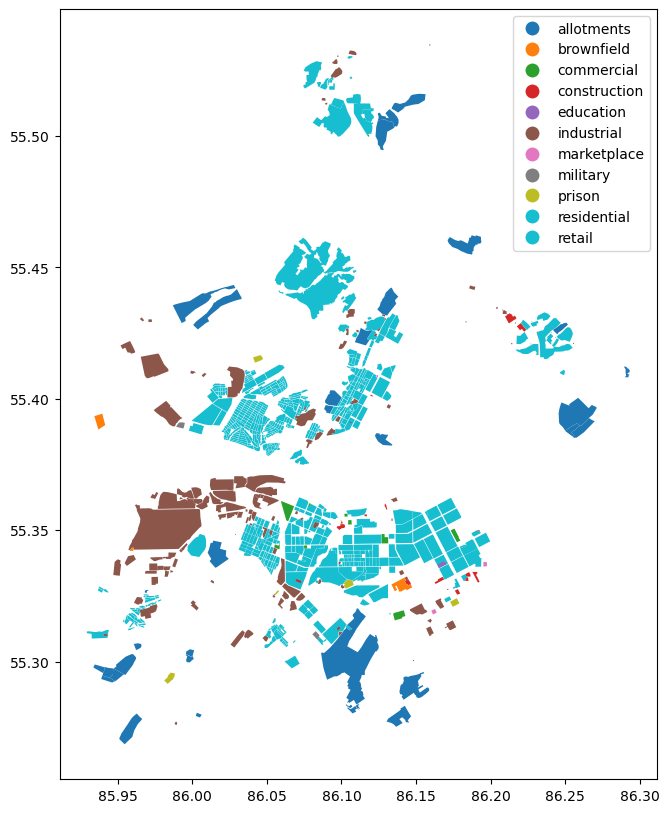

In [43]:
from fire_units.settings import LANDUSE_TAGS

# Загрузка данных о границых застройки по полигону границ
landuses = ox.features.features_from_polygon(borders.union_all(), LANDUSE_TAGS)
# Оставляем только данные с геометрией Полигон или Мультиполигон
landuses = landuses[landuses.geometry.apply(lambda x: x.geom_type).isin(['Polygon', 'MultiPolygon'])]
# Удаляем индекс по типу элемента и устанавливаем индекс 'id'
landuses = landuses.reset_index().drop('element', axis=1).set_index('id')

# Оставляем только нужные поля
landuses = landuses[['landuse','name','amenity','geometry']]

# Исправление типов землепользования по полю `amenity`
for lid, data in landuses[landuses['amenity'].notna()].iterrows():
    landuses.loc[lid, 'landuse'] = data['amenity']

# Проверяем количество записей и полей
print(landuses.shape)

# Печатаем карту
landuses.plot(column='landuse', legend=True, figsize=(10,10))

### Исправление назначения зданий {.unnumbered}

In [44]:
import re
from genesis.utils import Progressbar
from lists import BUILDINGS_CLASS

# Список значений `building` нуждающихся в проверке
bldngs_need_for_check = [
 'yes', 'roof', 'yes;college', 'no'
]

# Приведение наборов в единую систему координат
landuses = ox.projection.project_gdf(landuses)
buildings = ox.projection.project_gdf(buildings, to_crs=landuses.crs)

# Дополнение данных о зданиях данными по amenity
buildings_for_check = buildings.query(f'building in {bldngs_need_for_check}')
pb = Progressbar(len(buildings_for_check))
for bid, data in buildings_for_check.iterrows():
    pb()
    if data['amenity'] != '':
        buildings.loc[bid, 'building'] = data['amenity']

# Дополнение данных о зданиях  данными по landuse
pb = Progressbar(len(buildings_for_check))
for bid, data in buildings_for_check.iterrows():
    pb()
    g = data['geometry']
    intersected = landuses[landuses.intersects(g)]
    if len(intersected) >= 1:
        landuse = intersected.iloc[0]['landuse']
        buildings.loc[bid, 'building'] = landuse

# Переименовываем английские названия на русский язык
buildings['building'] = buildings['building'].fillna('неизвестно')
buildings['building'] = buildings['building'].replace(BUILDINGS_CLASS)
# Для английских названий, которых нет в списке BUILDINGS_CLASS, устанавливаем 'неизвестно'
for bld_class in buildings['building'].unique():
    if re.match('^[a-zA-Z]', bld_class) is not None and bld_class not in BUILDINGS_CLASS:    
        buildings.loc[buildings['building']==bld_class, 'building'] = 'неизвестно'

# Печать типов зданий исходя из назначения
buildings.groupby('building').count().sort_values('geometry', ascending=False)['geometry']

|########################################| 100.0%
|########################################| 100.0%


building
Многоквартирный жилой дом       18581
неизвестно                      15428
Жилой дом                        1298
Производственное здание          1213
Дача                              184
Коммерческое здание               100
Гараж                              89
Строительство                      87
Административное здание            76
Торговое здание                    65
Школа                              50
Тюрьма                             42
Детский сад                        40
Больница                           36
АЗС                                34
Общежитие                          29
ВУЗ                                23
Церковь                            23
Здание общественного питания       22
Общественное здание                16
Резервуар                          11
Автомойка                          10
Заброшено                           9
Служебная постройка                 8
Пожарная часть                      7
Ангар                               6
Скл

### Сохранение результатов {.unnumbered}

In [45]:
from lists import ALLOTMENTS

# Переименовываем землепользование на русский язык
landuses['landuse'] = landuses['landuse'].replace(ALLOTMENTS)

# Перепроецируем наборы данных в географическую СК (EPSG:4326)
buildings = ox.projection.project_gdf(buildings, to_latlong=True)
landuses =ox.projection.project_gdf(landuses, to_latlong=True)

# Сохраняем
buildings.to_file('data/kemerovo/buildings.gpkg', layer='здания')
landuses.to_file('data/kemerovo/landuse.gpkg', layer='землепользование')

## Данные о пожарных подразделениях

Данные о пожарных подразделениях могут быть загружены из OSM или из имеющихся таблиц (баз данных).

Выгрузка из OSM не гарантирует наличия точных сведений, но часто это оказывается наиболее доступный способ.

### Загрузка из OpenStreetMap {.unnumbered}

C:\Users\obsid\AppData\Local\Temp\ipykernel_14420\1516083545.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  units['geometry'] = units.geometry.centroid


Набор подразделений: (37530, 8)


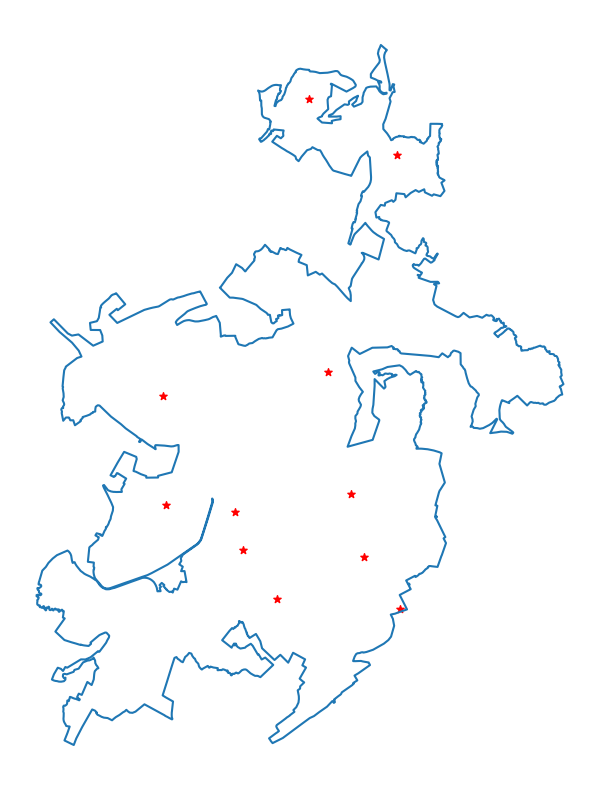

In [ ]:
# Тег OSM для зданий
tags = {'amenity': 'fire_station'}

# Словарь полей, которые следует оставить в наборе. Если не использовать, будут сохранены излишние данные
fields = [
    'name',
    'operator',
    'fire_station:type',
    'addr:street',
    'addr:housenumber',
    'geometry',
]


# Загрузка набора данных  из OSM
units = ox.features_from_polygon(borders.union_all(), tags)
# Приводим геометрию к точке
units['geometry'] = units.geometry.centroid
# Оставляем только заданные поля (и при этом имеющиеся в списке полученных)
fields = list(set(buildings.columns) & set(fields))
units = units[fields]
# Удаляем индекс по типу элемента
units = units.reset_index().drop('element', axis=1)
# Устанавливаем индекс 'id'
units = units.set_index('id')

# Проверяем количество записей и полей
print('Набор подразделений:', buildings.shape)

# Печать на карте
ax = borders.boundary.plot(figsize=(10,10))
units.plot(ax=ax, markersize=30, marker='*', color='r')
ax.set_axis_off()

### Загрузка из файлов csv {.unnumbered}

В ряде случаев данные о пожарных подразделениях могут храниться в таких форматах как Excel или csv. Ниже приведен приер загрузки данных о ПСЧ из файла csv.

In [73]:
# Загрузка из файла
units = pd.read_csv('data/kemerovo/fire_units.csv')

# Преобразование формата широты и долготы к float
units['Широта'] = units['Широта'].astype(float)
units['Долгота'] = units['Долгота'].astype(float)

# Перевод в GeoDataFrame
units = gpd.GeoDataFrame(
        units, geometry=gpd.points_from_xy(units['Долгота'], units['Широта']), crs=borders.crs
    )

# Печать данных
units

,name,unit_type,Широта,Долгота,Адрес,geometry
0,4 ПСЧ 1 ПСО ФПС ГПС ГУ МЧС России по Кемеровск...,ФПС,55.410249,86.121353,"Кемеровская область - Кузбасс, г. Кемерово, ул...",POINT (86.12135 55.41025)
1,2 ПСЧ 1 ПСО ФПС ГПС ГУ МЧС России по Кемеровс...,ФПС,55.316790,86.083784,"Кемеровская область - Кузбасс, г. Кемерово, ул...",POINT (86.08378 55.31679)
2,1 ПСЧ 1 ПСО ФПС ГПС ГУ МЧС России по Кемеровск...,ФПС,55.359574,86.138069,"Кемеровская область - Кузбасс, г. Кемерово, ул...",POINT (86.13807 55.35957)
3,5 ПСЧ 1 ПСО ФПС ГПС ГУ МЧС России по Кемеровск...,ФПС,55.333876,86.146783,"Кемеровская область - Кузбасс, г. Кемерово, ул...",POINT (86.14678 55.33388)
4,3 ПСЧ 1 ПСО ФПС ГПС ГУ МЧС России по Кемеровск...,ФПС,55.400358,86.001489,"Кемеровская область - Кузбасс, г. Кемерово, ул...",POINT (86.00149 55.40036)
5,СПСЧ ФПС ГПС ГУ МЧС России по Кемеровской обла...,ФПС,55.352629,86.053484,"Кемеровская область - Кузбасс, г.Кемерово ул. ...",POINT (86.05348 55.35263)
6,7 ПСЧ 1 ПСО ФПС ГПС ГУ МЧС России по Кемеровск...,ФПС,55.522765,86.107239,"Кемеровская область - Кузбасс, г.Кемерово, ж.р...",POINT (86.10724 55.52276)
7,ОП 7 ПСЧ 1 ПСО ФПС ГПС ГУ МЧС России по Кемеро...,ФПС,55.499469,86.171441,"Кемеровская область - Кузбасс, г.Кемерово, ж.р...",POINT (86.17144 55.49947)


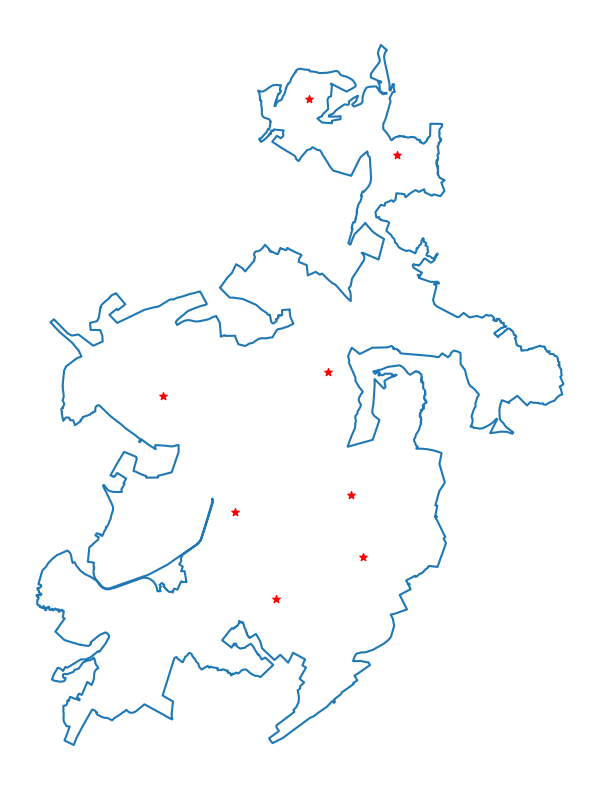

In [74]:
# Печать на карте
ax = borders.boundary.plot(figsize=(10,10))
units.plot(ax=ax, markersize=30, marker='*', color='r')
ax.set_axis_off()

### Сохранение набора данных {.unnumbered}

In [76]:
units.to_file('data/kemerovo/fire_units.gpkg', layer='подразделения')

Граф улично-дорожной сети (ГДС) является основным видом данных используемых в `genesis`. Он используется для расчета времени прибытия подразделений пожарной охраны и оценки параметров их прибытия на территории населенного пункта.

# Подготовка рабочих наборов данных

Для окончательной доработки исходных данных, а также для их корректировки в повседневном режиме рекомендуется использование приложения QGIS.

## Создание проекта QGIS

Создание нового проекта QGIS:

1. Запустите приложение QGIS
2. Создайте пустой проект
![](imgs/data_prep_0.png)
3. Сохраните проект в удобную папку, желательно в папку в которой хранятся слои с данными
![](imgs/data_prep_1.png)
![](imgs/data_prep_2.png)
4. Найдите слои с данными в браузере данных и добавьте слой в проект, перетащив их на поле карты или в окно слоев
![](imgs/data_prep_3.png)
![](imgs/data_prep_4.png)
5. Установите локальную СК проекта
![](imgs/data_prep_5.png)
6. Переименуйте и настройте слои
![](imgs/data_prep_6.png)

### Визуальное редактирование данных {.unnumbered}

Для визуального редактирования данных (геометрии объектов) используется окно пользовательского интерфейса приложения QGIS.

![](imgs/data_prep_7.png)

Для редактирования слоя следует включить режим редактирования (1).

В режиме редактирования можно выполнить следующие действия:

* добавить новый объект нанеся его на карту (2)
* изменить контуры объекта (3)
* выбрать объект или группу объектов (6)
* удалить объект (4). Удалить можно только выбранный объект

### Редактирование атрибутивных данных {.unnumbered}

Для редактирования атрибутивных данных через пользовательский интерфейс приложения `QGIS` следует воспользоваться кнопкой `Определить объекты` (1).

![](imgs/data_prep_8.png) 

Выбрать в окне карты интересующий объект (2), после чего в окне `Результат определения` (3) воспользоваться кнопкой `Открыть форму объекта` (4).

Далее в окне `Атрибуты объектов` можно внести требуемые изменения, например, указать назначение здания.

Для редактирования атрибутивных данных через *таблицу атрибутов*, следует воспользоваться кнопкой `Таблица атрибутов` (5), после чего откроется окно таблицы данных.

![](imgs/data_prep_9.png)

Используя таблицу данных можно изменять атрибутивные данные объектов непосредственно в таблице.

По завершении внесения правок в объект слоя, следует выйти из режима редактирования.

![](imgs/data_prep_10.png)